## Check SOCAT final distribution split

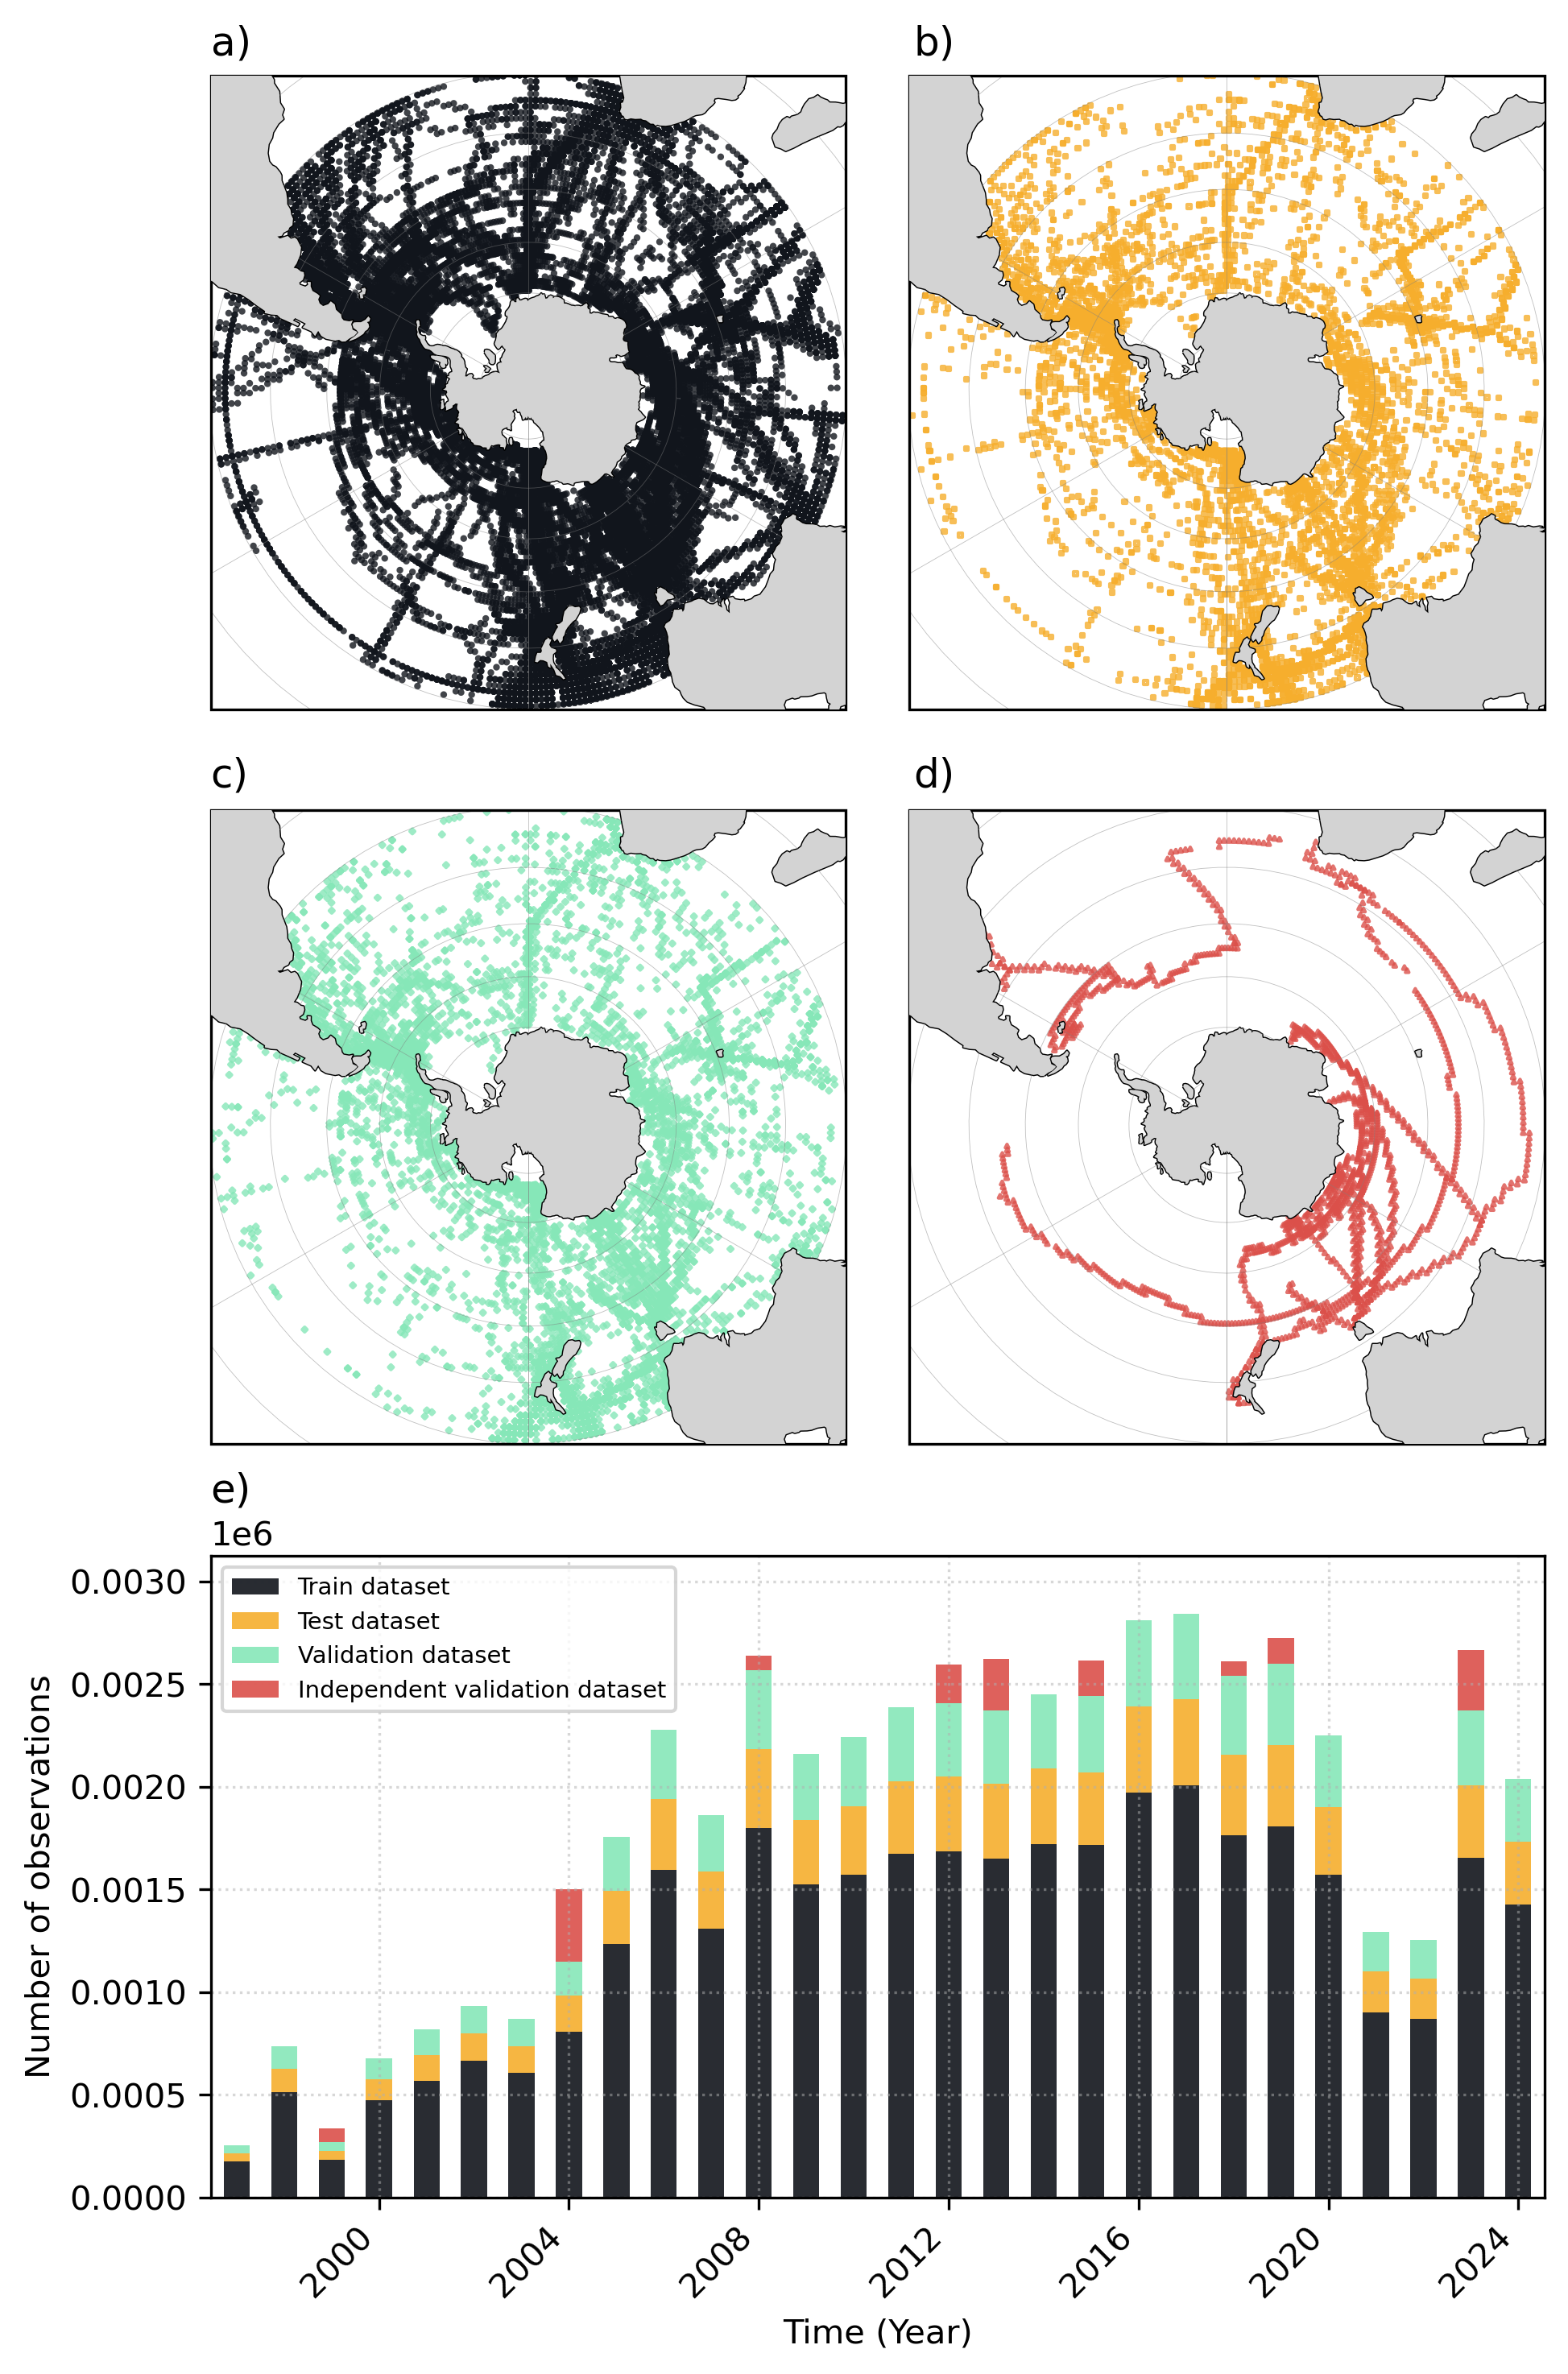

In [1]:
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# === Load datasets ===
datasets = {
    "train_data": pd.read_csv("/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/pco2_train_data.csv"),
    "test_data": pd.read_csv("/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/pco2_test_data.csv"),
    "validation_data": pd.read_csv("/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/pco2_validation_data.csv"),
    "independent_validation_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/independent_validation/pco2_independent_validation_data_regridded_SLA_RRS_PAR_WIND_ATM_CO2_feature_engineered_monthly_1deg_pCO2.csv"
    )
}

# === FIX COORDINATES FOR INDEPENDENT DATA ===
if "lat_center" in datasets["independent_validation_data"].columns:
    datasets["independent_validation_data"].rename(
        columns={"lat_center": "latitude", "lon_center": "longitude"},
        inplace=True
    )

# === ENSURE month_center EXISTS FOR *ALL* DATASETS ===
for key, df in datasets.items():

    if "month_center" in df.columns:
        df["month_center"] = pd.to_datetime(df["month_center"], errors="coerce")

    else:
        df["month_center"] = pd.to_datetime(
            dict(
                year=df["year"],
                month=df["month"],
                day=df["day"],
                hour=df["hour"],
                minute=df["minute"],
                second=df["second"],
            ),
            errors="coerce"
        )

def plot_data(datasets):

    colors = ['#11151C', '#F6AE2D', '#86E7B8', '#DB504A']
    markers = ['o', 's', 'D', '^']
    label_map = {
        "train_data": "Train dataset",
        "test_data": "Test dataset",
        "validation_data": "Validation dataset",
        "independent_validation_data": "Independent validation dataset"
    }

    ordered_keys = ["train_data", "test_data", "validation_data", "independent_validation_data"]

    fig = plt.figure(figsize=(6, 10), dpi=300)
    gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, -0.12, 1])

    # === MAPS (ALL 4 DATASETS) ===
    for i, key in enumerate(ordered_keys):
        row, col = divmod(i, 2)

        ax = fig.add_subplot(gs[row, col], projection=ccrs.SouthPolarStereo())
        ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
        ax.coastlines(resolution='110m', linewidth=0.7)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=12)
        ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

        df = datasets[key]

        if "latitude" not in df.columns or "longitude" not in df.columns:
            raise ValueError(f"{key} is missing latitude/longitude columns.")

        ax.scatter(
            df['longitude'], df['latitude'],
            s=1, facecolors='none',
            edgecolors=colors[i],
            marker=markers[i],
            alpha=0.8,
            transform=ccrs.PlateCarree()
        )

    # === YEARLY STACKED HISTOGRAM (ALL 4 DATASETS) ===
    ax_hist = fig.add_subplot(gs[3, :])

    hist_keys = ordered_keys
    hist_colors = colors

    # Build global YEAR axis from ALL datasets
    min_year = min(datasets[k]["month_center"].dt.year.min() for k in hist_keys)
    max_year = max(datasets[k]["month_center"].dt.year.max() for k in hist_keys)

    all_years = pd.period_range(
        start=f"{min_year}",
        end=f"{max_year}",
        freq="Y"
    )

    all_years_datetime = all_years.to_timestamp()

    bar_width = 200  # days (wide since yearly)
    bottom = np.zeros(len(all_years_datetime))

    for key, color in zip(hist_keys, hist_colors):

        df = datasets[key]

        yearly_counts = (
            df["month_center"]
            .dt.to_period("Y")
            .value_counts()
            .reindex(all_years, fill_value=0)
            .sort_index()
        )

        ax_hist.bar(
            all_years_datetime,
            yearly_counts.values,
            width=bar_width,
            bottom=bottom,
            color=color,
            alpha=0.9,
            label=label_map[key]
        )

        bottom += yearly_counts.values

    ax_hist.set_xlim(
        all_years_datetime.min() - pd.Timedelta(days=200),
        all_years_datetime.max() + pd.Timedelta(days=200)
    )

    # Add a little headroom above the tallest stacked bar (e.g. +10%)
    ymax = bottom.max()
    ax_hist.set_ylim(0, ymax * 1.1)

    ax_hist.set_xlabel("Time (Year)")
    ax_hist.set_ylabel("Number of observations")
    ax_hist.grid(True, linestyle=":", alpha=0.5)
    ax_hist.ticklabel_format(axis="y", style="sci", scilimits=(6, 6))
    ax_hist.legend(loc="upper left", fontsize=7)

    plt.setp(ax_hist.get_xticklabels(), rotation=45, ha="right")

    # === PANEL TAGS ===
    tags = ["a)", "b)", "c)", "d)", "e)"]
    positions = [
        (0.05, 0.967), (0.535, 0.967),
        (0.05, 0.664), (0.535, 0.664),
        (0.05, 0.368)
    ]

    for (x, y), tag in zip(positions, tags):
        fig.text(x, y, tag, fontsize=12)

    plt.subplots_adjust(left=0.05, right=0.97, top=0.96, bottom=0.08, wspace=0.1)

    plt.savefig("figs/HDBSCAN_split_overview.png", dpi=300, bbox_inches='tight')
    plt.show()


plot_data(datasets)


## SOCATv2025 independent validation

In [2]:
import pandas as pd

# df = pd.read_csv(
#     "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_SOCAT_ONLY_OBS_v2/models/MC_ensemble/independent_predictions/MC_independent_validation_predictions.csv"
# )

df = pd.read_csv("/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/models/30S/MC_ensemble//independent_predictions/MC_independent_validation_predictions.csv")

In [3]:
df

,month_center,lat_center,lon_center,depth,MLD,ARMOR3D_temperature,ARMOR3D_salinity,fco2_rec_median,SOCAT_temperature,SOCAT_salinity,...,pco2_pred_MCmodel_992,pco2_pred_MCmodel_993,pco2_pred_MCmodel_994,pco2_pred_MCmodel_995,pco2_pred_MCmodel_996,pco2_pred_MCmodel_997,pco2_pred_MCmodel_998,pco2_pred_MCmodel_999,pco2_pred_MCmodel_1000,ensemble_std
0,1999-08-01,-67.5,145.5,0.0,15.00,-1.7950,34.3915,399.1540,-1.8730,34.6120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999-07-01,-66.5,143.5,0.0,18.70,-1.7980,34.2740,400.5855,-1.8600,34.4375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1999-08-01,-66.5,143.5,0.0,15.00,-1.7980,34.2880,398.5635,-1.8930,34.6425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1999-08-01,-66.5,144.5,0.0,15.00,-1.7980,34.2800,403.4860,-1.8630,34.4830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999-08-01,-66.5,145.5,0.0,15.00,-1.7970,34.2700,405.0185,-1.8600,34.5190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,2023-03-01,-33.5,-53.5,0.0,14.10,24.7210,31.2890,495.5200,23.7860,34.0345,...,443.21347,294.34933,406.05740,447.45804,313.32816,155.38785,394.51850,322.83414,425.78677,62.059080
1597,2023-03-01,-33.5,-52.5,0.0,14.70,24.1335,31.5345,500.0310,23.5110,33.9090,...,445.90637,450.80417,457.83770,445.25310,440.27500,447.18112,438.42140,447.24140,447.78577,8.337497
1598,2023-02-01,-33.5,17.5,0.0,13.95,18.0825,35.4225,372.1850,21.4810,34.1290,...,364.50766,378.17886,369.54373,344.30930,379.58580,352.04526,382.34290,382.40634,374.72974,17.228716
1599,2023-04-01,-32.5,-51.5,0.0,15.00,22.2415,32.3095,425.4360,23.4150,33.4360,...,447.33826,443.66022,440.05087,454.33090,452.79816,440.75340,442.31448,446.32642,452.01746,7.655886


Years present: [1999 2004 2008 2012 2013 2015 2018 2019 2023]


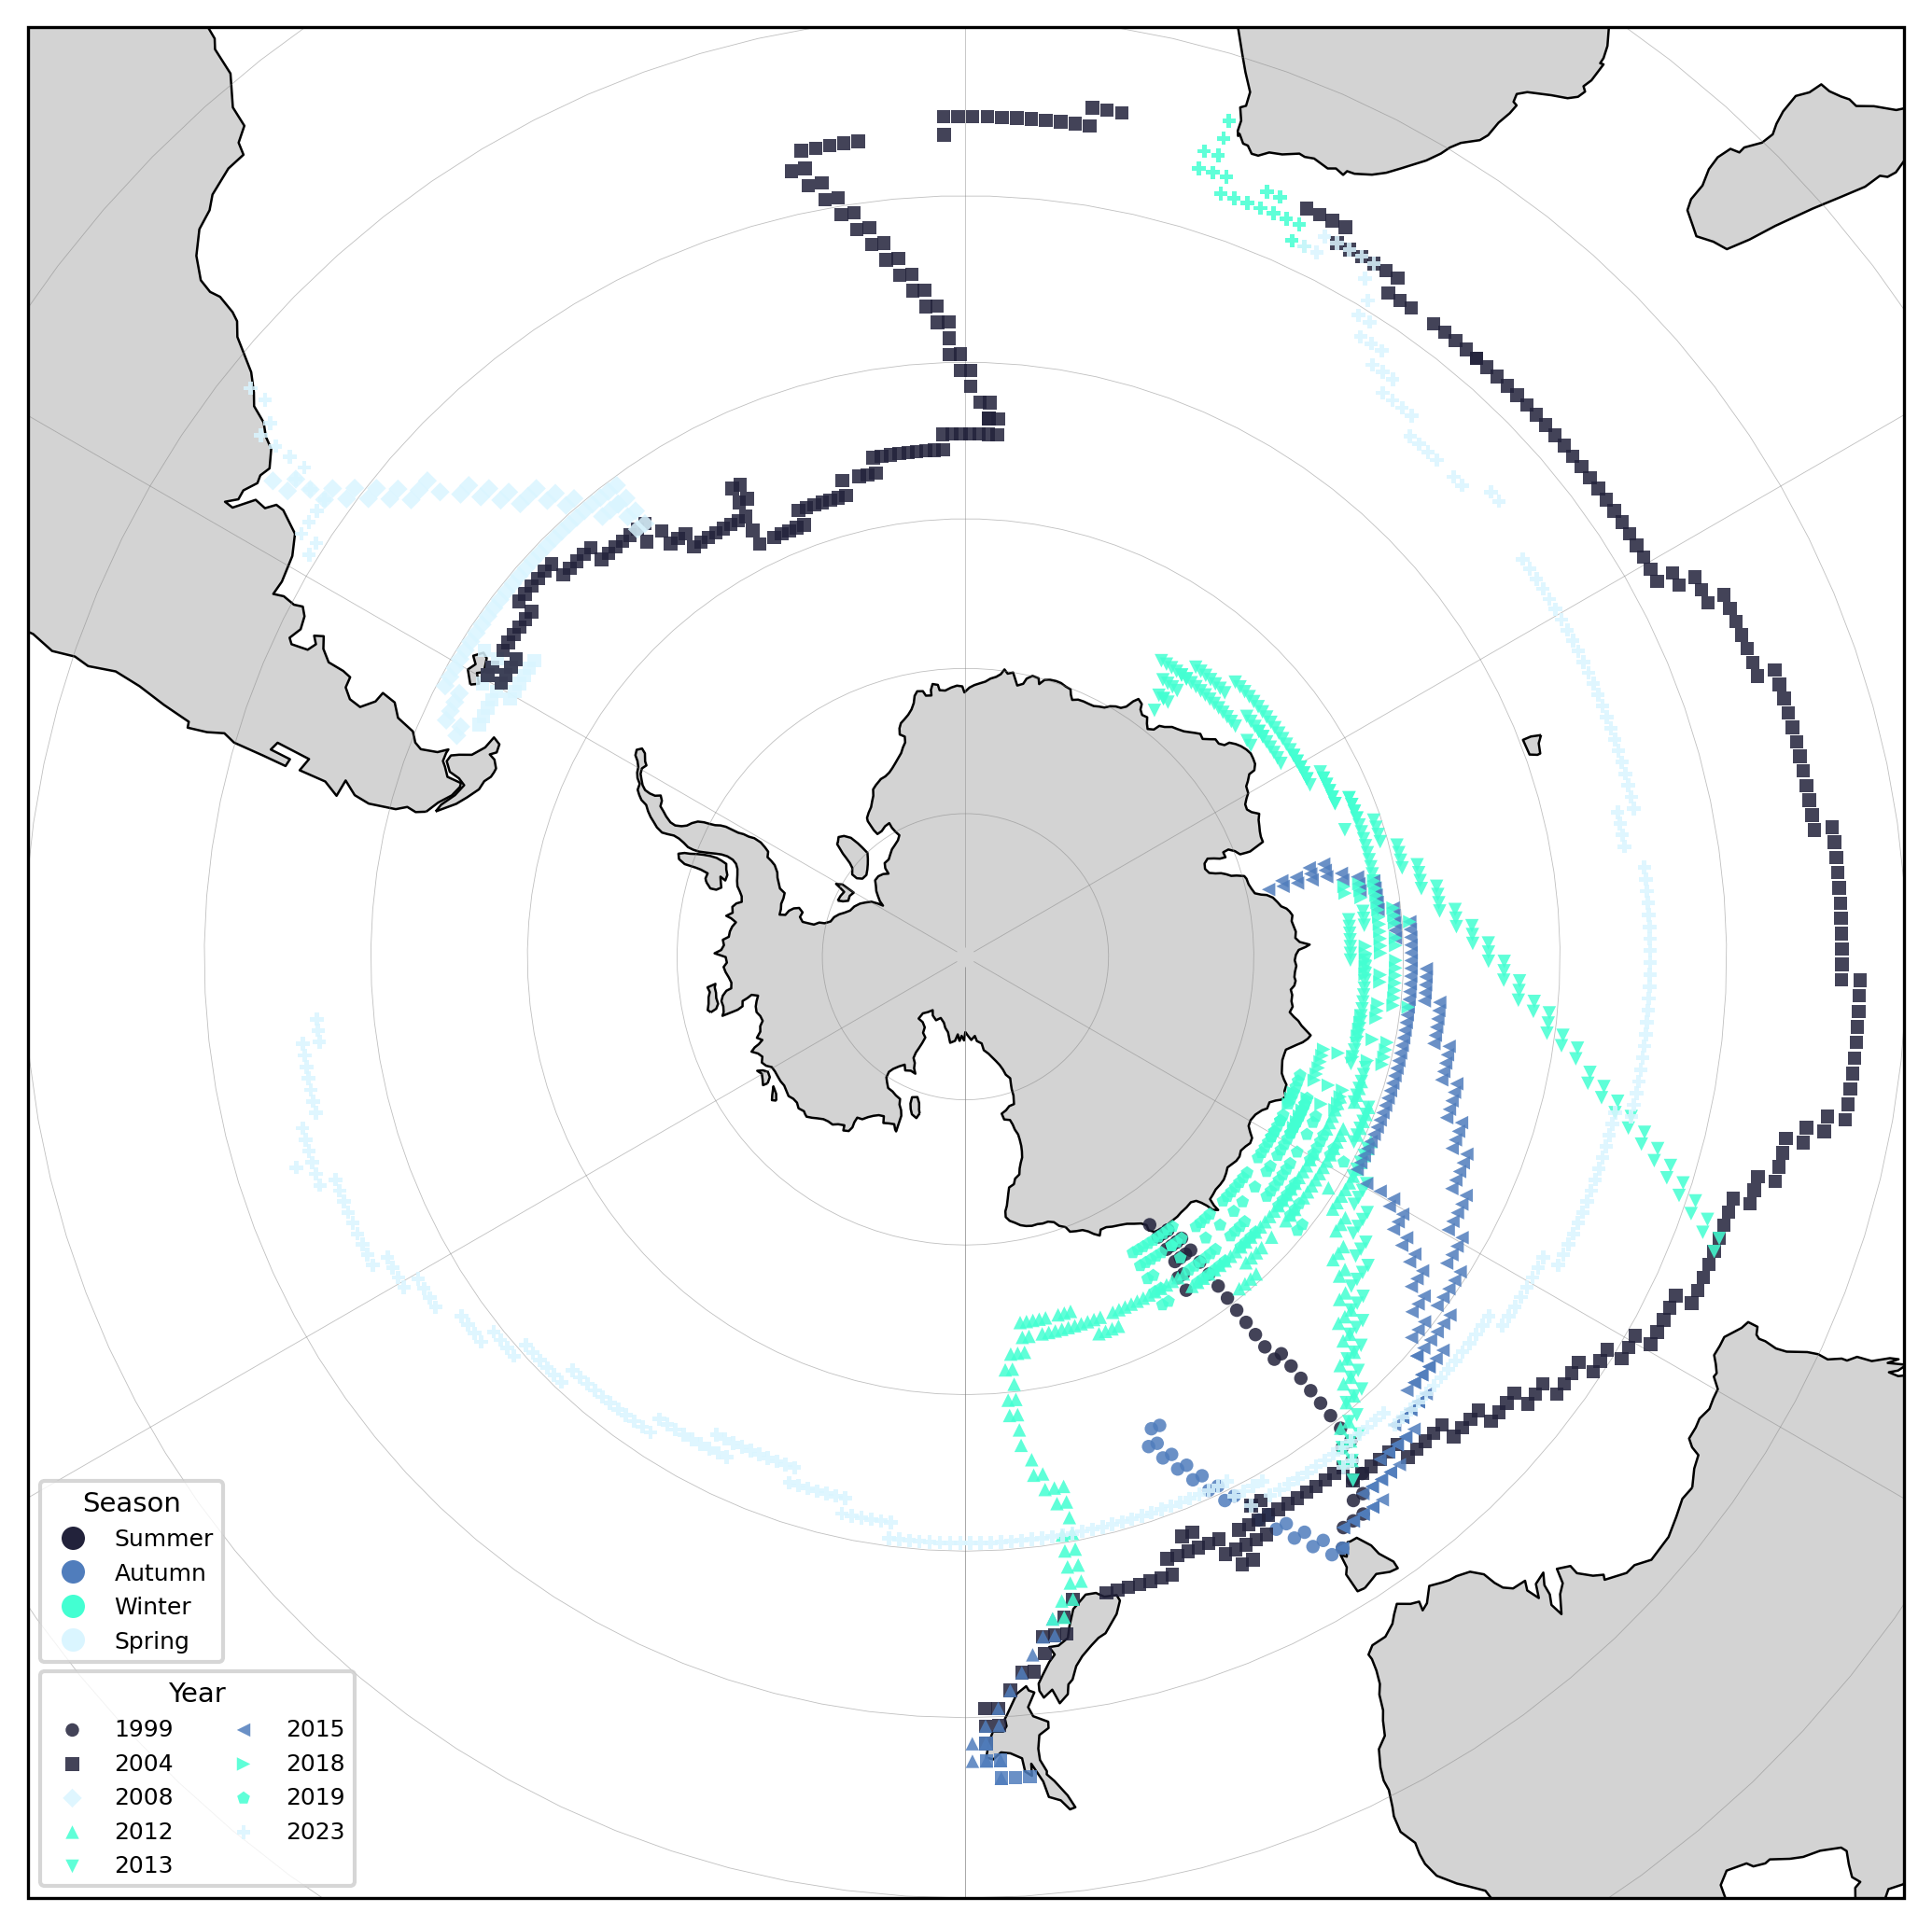

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.lines import Line2D

# -------------------------------
# Convert month_center to datetime, extract year + season
# -------------------------------
df["month_center"] = pd.to_datetime(df["month_center"], errors="coerce")
df["year"] = df["month_center"].dt.year
df["month"] = df["month_center"].dt.month

def month_to_season(month: int) -> str:
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Spring"
    elif month in (6, 7, 8):
        return "Summer"
    elif month in (9, 10, 11):
        return "Autumn"
    return np.nan

df["season"] = df["month"].apply(lambda m: month_to_season(int(m)) if pd.notna(m) else np.nan)

# -------------------------------
# Drop rows with missing info
# -------------------------------
df = df.dropna(subset=["year", "season", "lat_center", "lon_center"])

# -------------------------------
# Season colors
# -------------------------------
season_colors = {
    "Summer": "#22223b",
    "Autumn": "#507dbc",
    "Winter": "#43ffd2",
    "Spring": "#daf5ff",
}
season_order = ["Summer", "Autumn", "Winter", "Spring"]

# -------------------------------
# Year markers
# -------------------------------
years = np.sort(df["year"].unique())
print("Years present:", years)

year_markers = ['o','s','D','^','v','<','>','p','P','h','+','x','1','2','3','4']
year_to_marker = {yr: year_markers[i % len(year_markers)] for i, yr in enumerate(years)}

# -------------------------------
# Map
# -------------------------------
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

ax.coastlines(resolution="110m", linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.5)

# -------------------------------
# Plot: marker = year, color = season
# -------------------------------
for yr in years:
    df_y = df[df["year"] == yr]
    if df_y.empty:
        continue

    point_colors = df_y["season"].map(season_colors)

    ax.scatter(
        df_y["lon_center"],
        df_y["lat_center"],
        s=12,
        c=point_colors.values,
        marker=year_to_marker[yr],
        transform=ccrs.PlateCarree(),
        zorder=2,
        alpha=0.85,
        edgecolors="none",
        label=str(int(yr))
    )

# -------------------------------
# YEAR legend (markers)
# -------------------------------
year_legend = ax.legend(
    title="Year",
    loc="lower left",
    fontsize=6,
    title_fontsize=7,
    ncol=2,
    frameon=True,
)
ax.add_artist(year_legend)

# -------------------------------
# SEASON legend (colors)
# -------------------------------
season_handles = [
    Line2D([0],[0],
           marker='o',
           linestyle='None',
           markerfacecolor=season_colors[s],
           markeredgecolor='none',
           markersize=6,
           label=s)
    for s in season_order if s in df["season"].unique()
]

ax.legend(
    handles=season_handles,
    title="Season",
    loc="lower left",
    bbox_to_anchor=(0.0, 0.12),
    fontsize=6,
    title_fontsize=7,
    frameon=True
)

# -------------------------------
# Save & show
# -------------------------------
plt.tight_layout()
plt.savefig("figs/validation_points_year_marker_season_color.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# --- Season assignment function ---
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    elif month in [9, 10, 11]:
        return 'Spring'

# --- Convert month_center to datetime ---
df['month_center'] = pd.to_datetime(df['month_center'], errors='coerce')

# --- Extract month ---
df['month'] = df['month_center'].dt.month

# --- Assign season ---
df['season'] = df['month'].apply(get_season)

In [6]:
df.pco2.min()

np.float64(237.8995129076364)

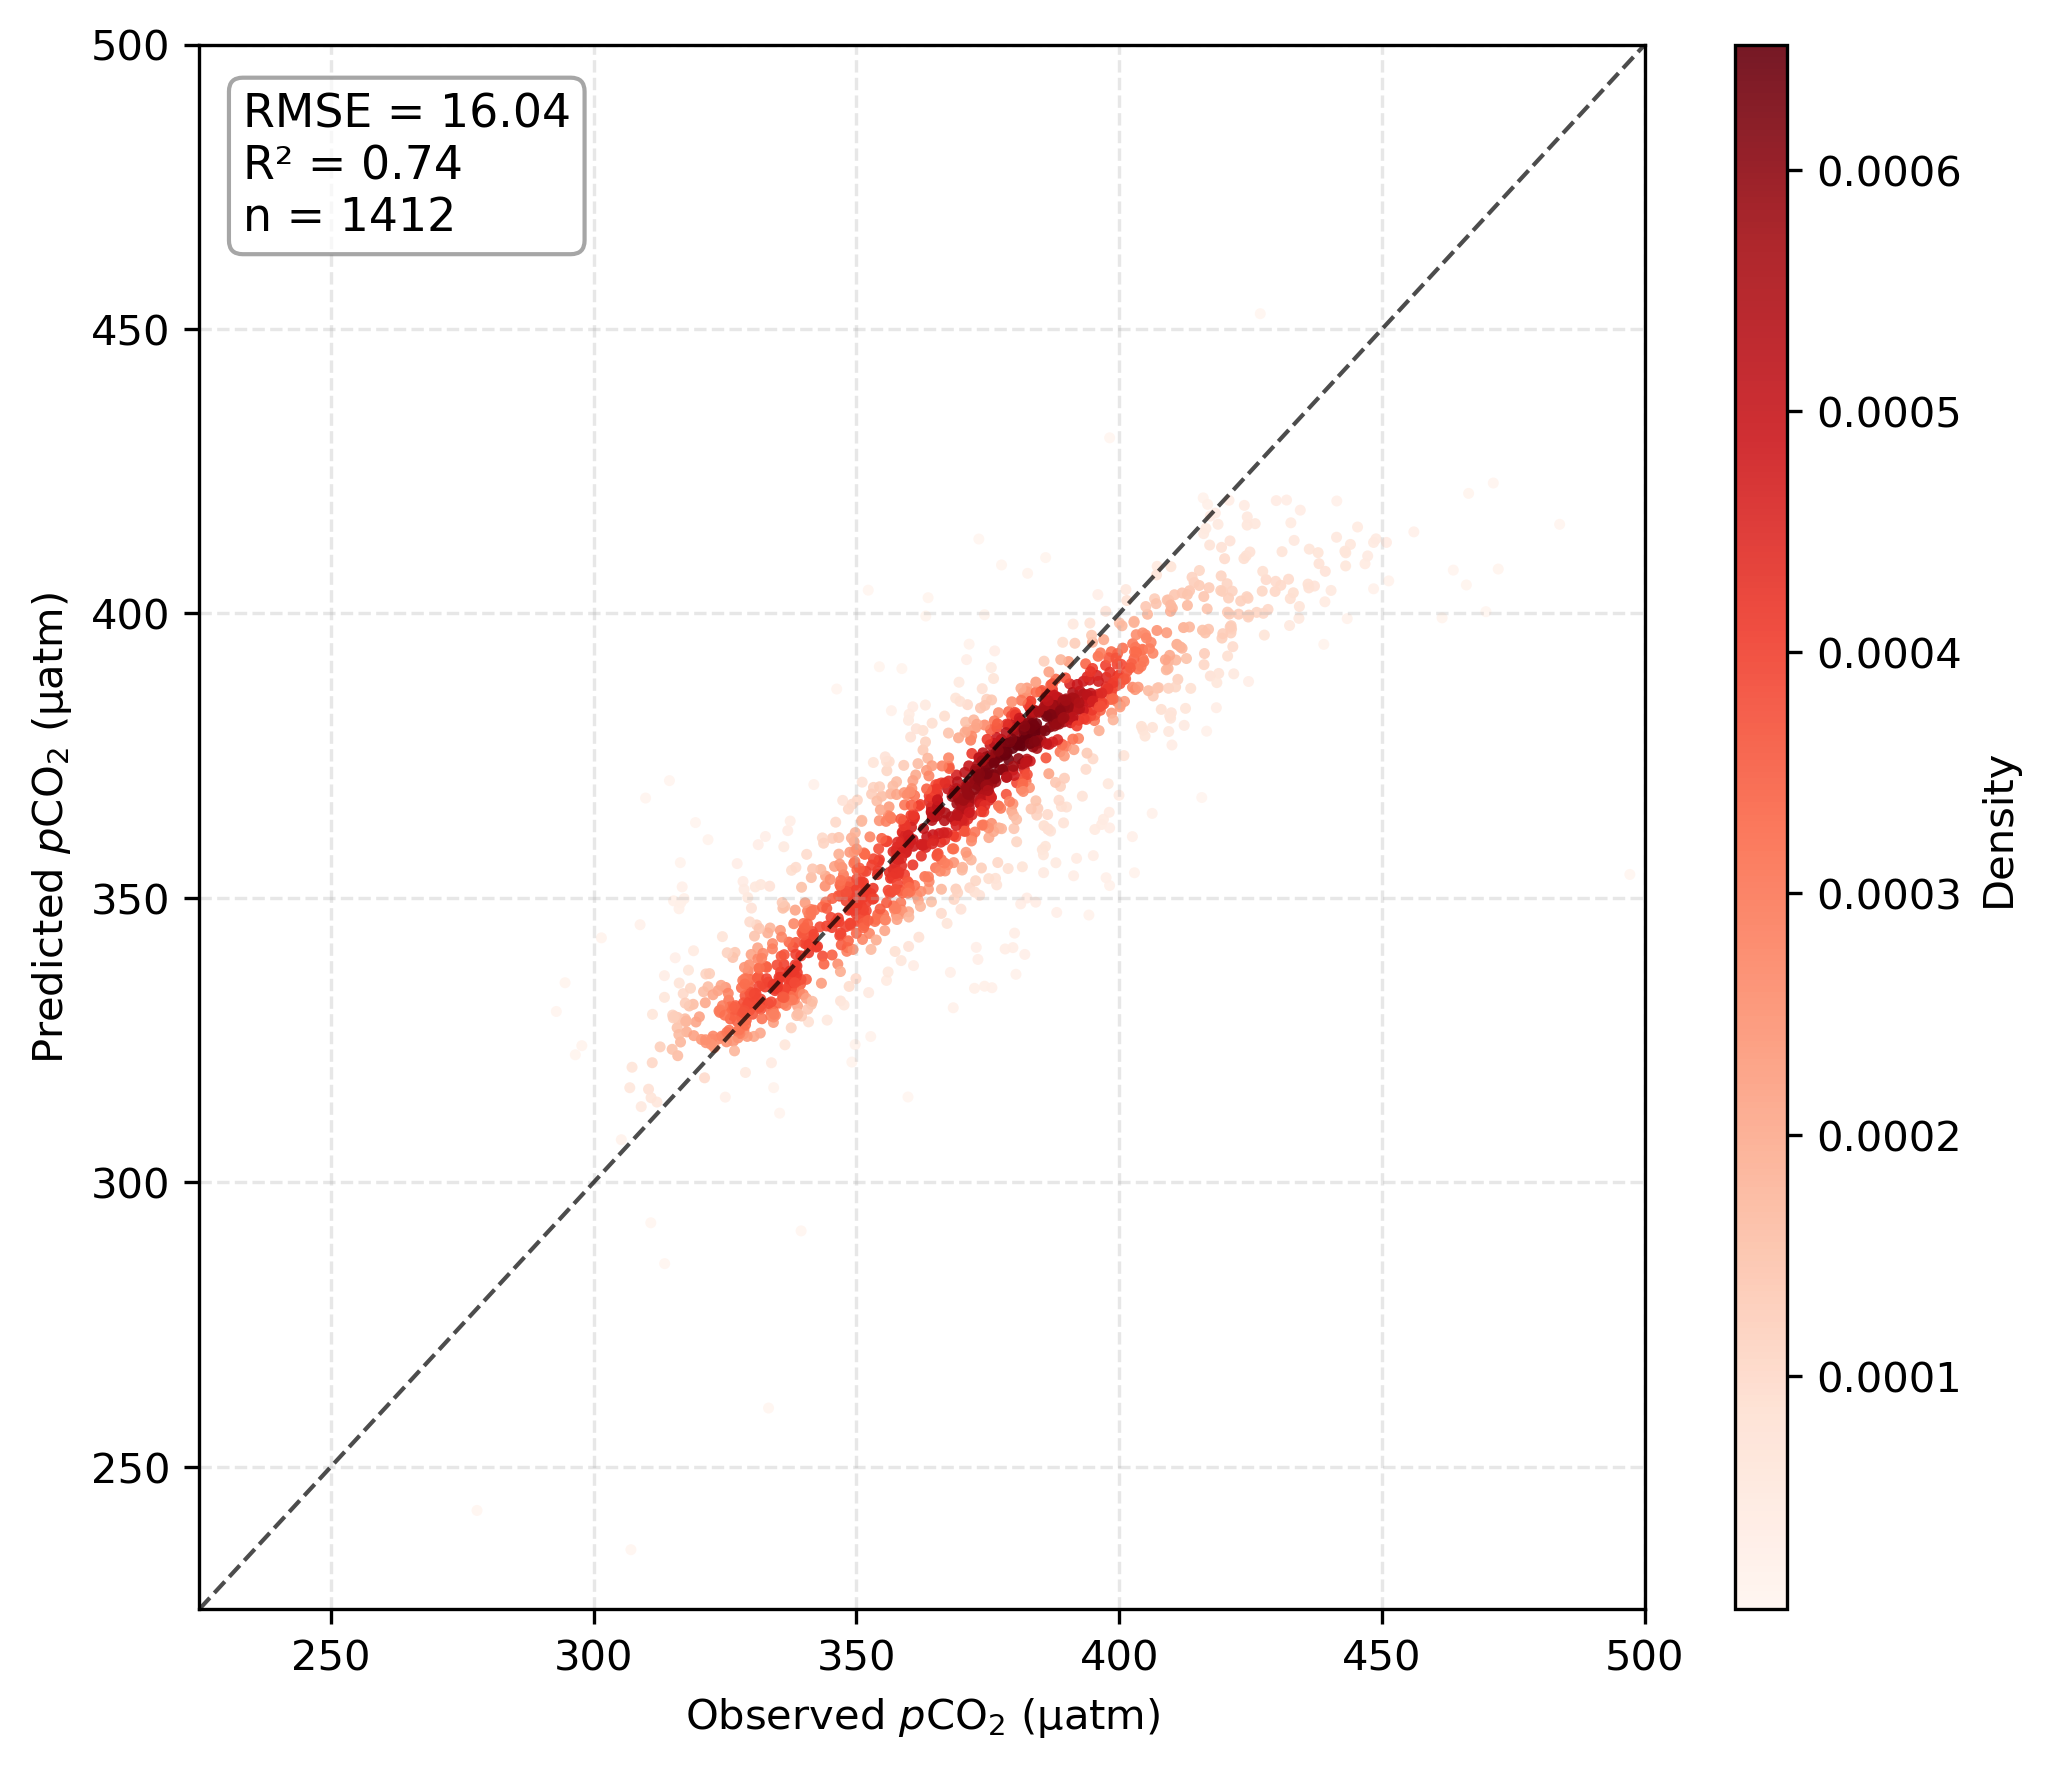

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde

# -------------------------------
# Select only needed columns and drop NaNs
# -------------------------------
df_valid = df[['pco2', 'ensemble_pco2_pred']].dropna()

x = df_valid['pco2'].values
y = df_valid['ensemble_pco2_pred'].values
n = len(df_valid)

# -------------------------------
# Compute point density using KDE
# -------------------------------
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sc = ax.scatter(
    x, y,
    c=density,
    s=7,
    alpha=0.9,
    edgecolor='none',
    cmap='Reds'
)

# Labels
ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.grid(True, ls='--', alpha=0.3)

# -------------------------------
# 1:1 line
# -------------------------------
min_pco2 = min(225, 225)
max_pco2 = max(500, 500)

ax.plot(
    [min_pco2, max_pco2],
    [min_pco2, max_pco2],
    'k--',
    lw=1,
    alpha=0.7
)

# Axis limits
ax.set_xlim(225, 500)
ax.set_ylim(225, 500)

# -------------------------------
# Colorbar
# -------------------------------
cbar = fig.colorbar(sc, ax=ax, label='Density', aspect=30)

# -------------------------------
# Metrics (NaN-safe, sklearn-safe)
# -------------------------------
rmse = np.sqrt(mean_squared_error(x, y))
r2 = r2_score(x, y)

# -------------------------------
# Stats box
# -------------------------------
stats_text = f"RMSE = {rmse:.2f}\nR² = {r2:.2f}\nn = {n}"

ax.text(
    0.03, 0.97, stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7)
)

# -------------------------------
# Save and show
# -------------------------------
fig.tight_layout()
fig.savefig("figs/pco2_density_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, r2_score

# Fit regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Define bins
bins = np.arange(300, 410, 10)

# Total number of points (for % calculation)
N_total = len(x)

# Pointwise bias
point_bias = y - x
bin_idx = np.digitize(x, bins)

# -----------------------------------------------------------
# 1. POINTWISE BIAS (Pred - Obs) + percentage of points
# -----------------------------------------------------------
pw_results = []
for i in range(1, len(bins)):
    mask = bin_idx == i
    n_bin = np.sum(mask)
    if n_bin > 0:
        pw_mean = np.mean(point_bias[mask])
        pct = (n_bin / N_total) * 100  # NEW
        pw_results.append([f"{bins[i-1]}–{bins[i]}", pw_mean, n_bin, pct])

pw_df = pd.DataFrame(pw_results, columns=["Bin (µatm)", "Mean Pointwise Bias (µatm)", "n", "% of dataset"])


# -----------------------------------------------------------
# 2. STRUCTURAL REGRESSION BIAS (Regression - 1:1)
#    + percentage of points in the bin
# -----------------------------------------------------------
reg_results = []
for i in range(len(bins)-1):
    x_mid = (bins[i] + bins[i+1]) / 2
    y_reg = slope * x_mid + intercept
    diff = y_reg - x_mid

    # % of data in this bin (same mask as above)
    mask = (bin_idx == i+1)
    pct = (np.sum(mask) / N_total) * 100  # NEW

    reg_results.append([f"{bins[i]}–{bins[i+1]}", x_mid, diff, pct])

reg_df = pd.DataFrame(reg_results, columns=["Bin (µatm)", "Bin Center", "Regression Bias (µatm)", "% of dataset"])


# -----------------------------------------------------------
# 3. Print results with explanations
# -----------------------------------------------------------

print("\n" + "="*70)
print("POINTWISE BIAS (Predicted − Observed)")
print("="*70)
print("Meaning:")
print(" This measures the actual model error in each bin.")
print(" The % column tells how much of the dataset falls in each bin.")
print(" A high % means the bias in that bin strongly affects overall model behavior.\n")
print(pw_df)

print("\n" + "="*70)
print("STRUCTURAL REGRESSION BIAS (Regression Line − 1:1 Line)")
print("="*70)
print("Meaning:")
print(" This measures systematic bias independent of noise.")
print(" The % column tells how much of the dataset occupies each bin.")
print(" A bin with very few points will have low influence on overall structural bias.\n")
print(reg_df)




POINTWISE BIAS (Predicted − Observed)
Meaning:
 This measures the actual model error in each bin.
 The % column tells you how much of the dataset falls in each bin.
 A high % means the bias in that bin strongly affects overall model behavior.

  Bin (µatm)  Mean Pointwise Bias (µatm)    n  % of dataset
0    300–310                   11.644572    8      0.566572
1    310–320                   15.740735   43      3.045326
2    320–330                    5.529054   88      6.232295
3    330–340                    0.922869  136      9.631728
4    340–350                    1.978816  111      7.861190
5    350–360                    0.469604  160     11.331445
6    360–370                   -0.560337  147     10.410765
7    370–380                   -4.396386  196     13.881020
8    380–390                   -7.440437  189     13.385269
9    390–400                  -11.711092  114      8.073654

STRUCTURAL REGRESSION BIAS (Regression Line − 1:1 Line)
Meaning:
 This measures systematic bia

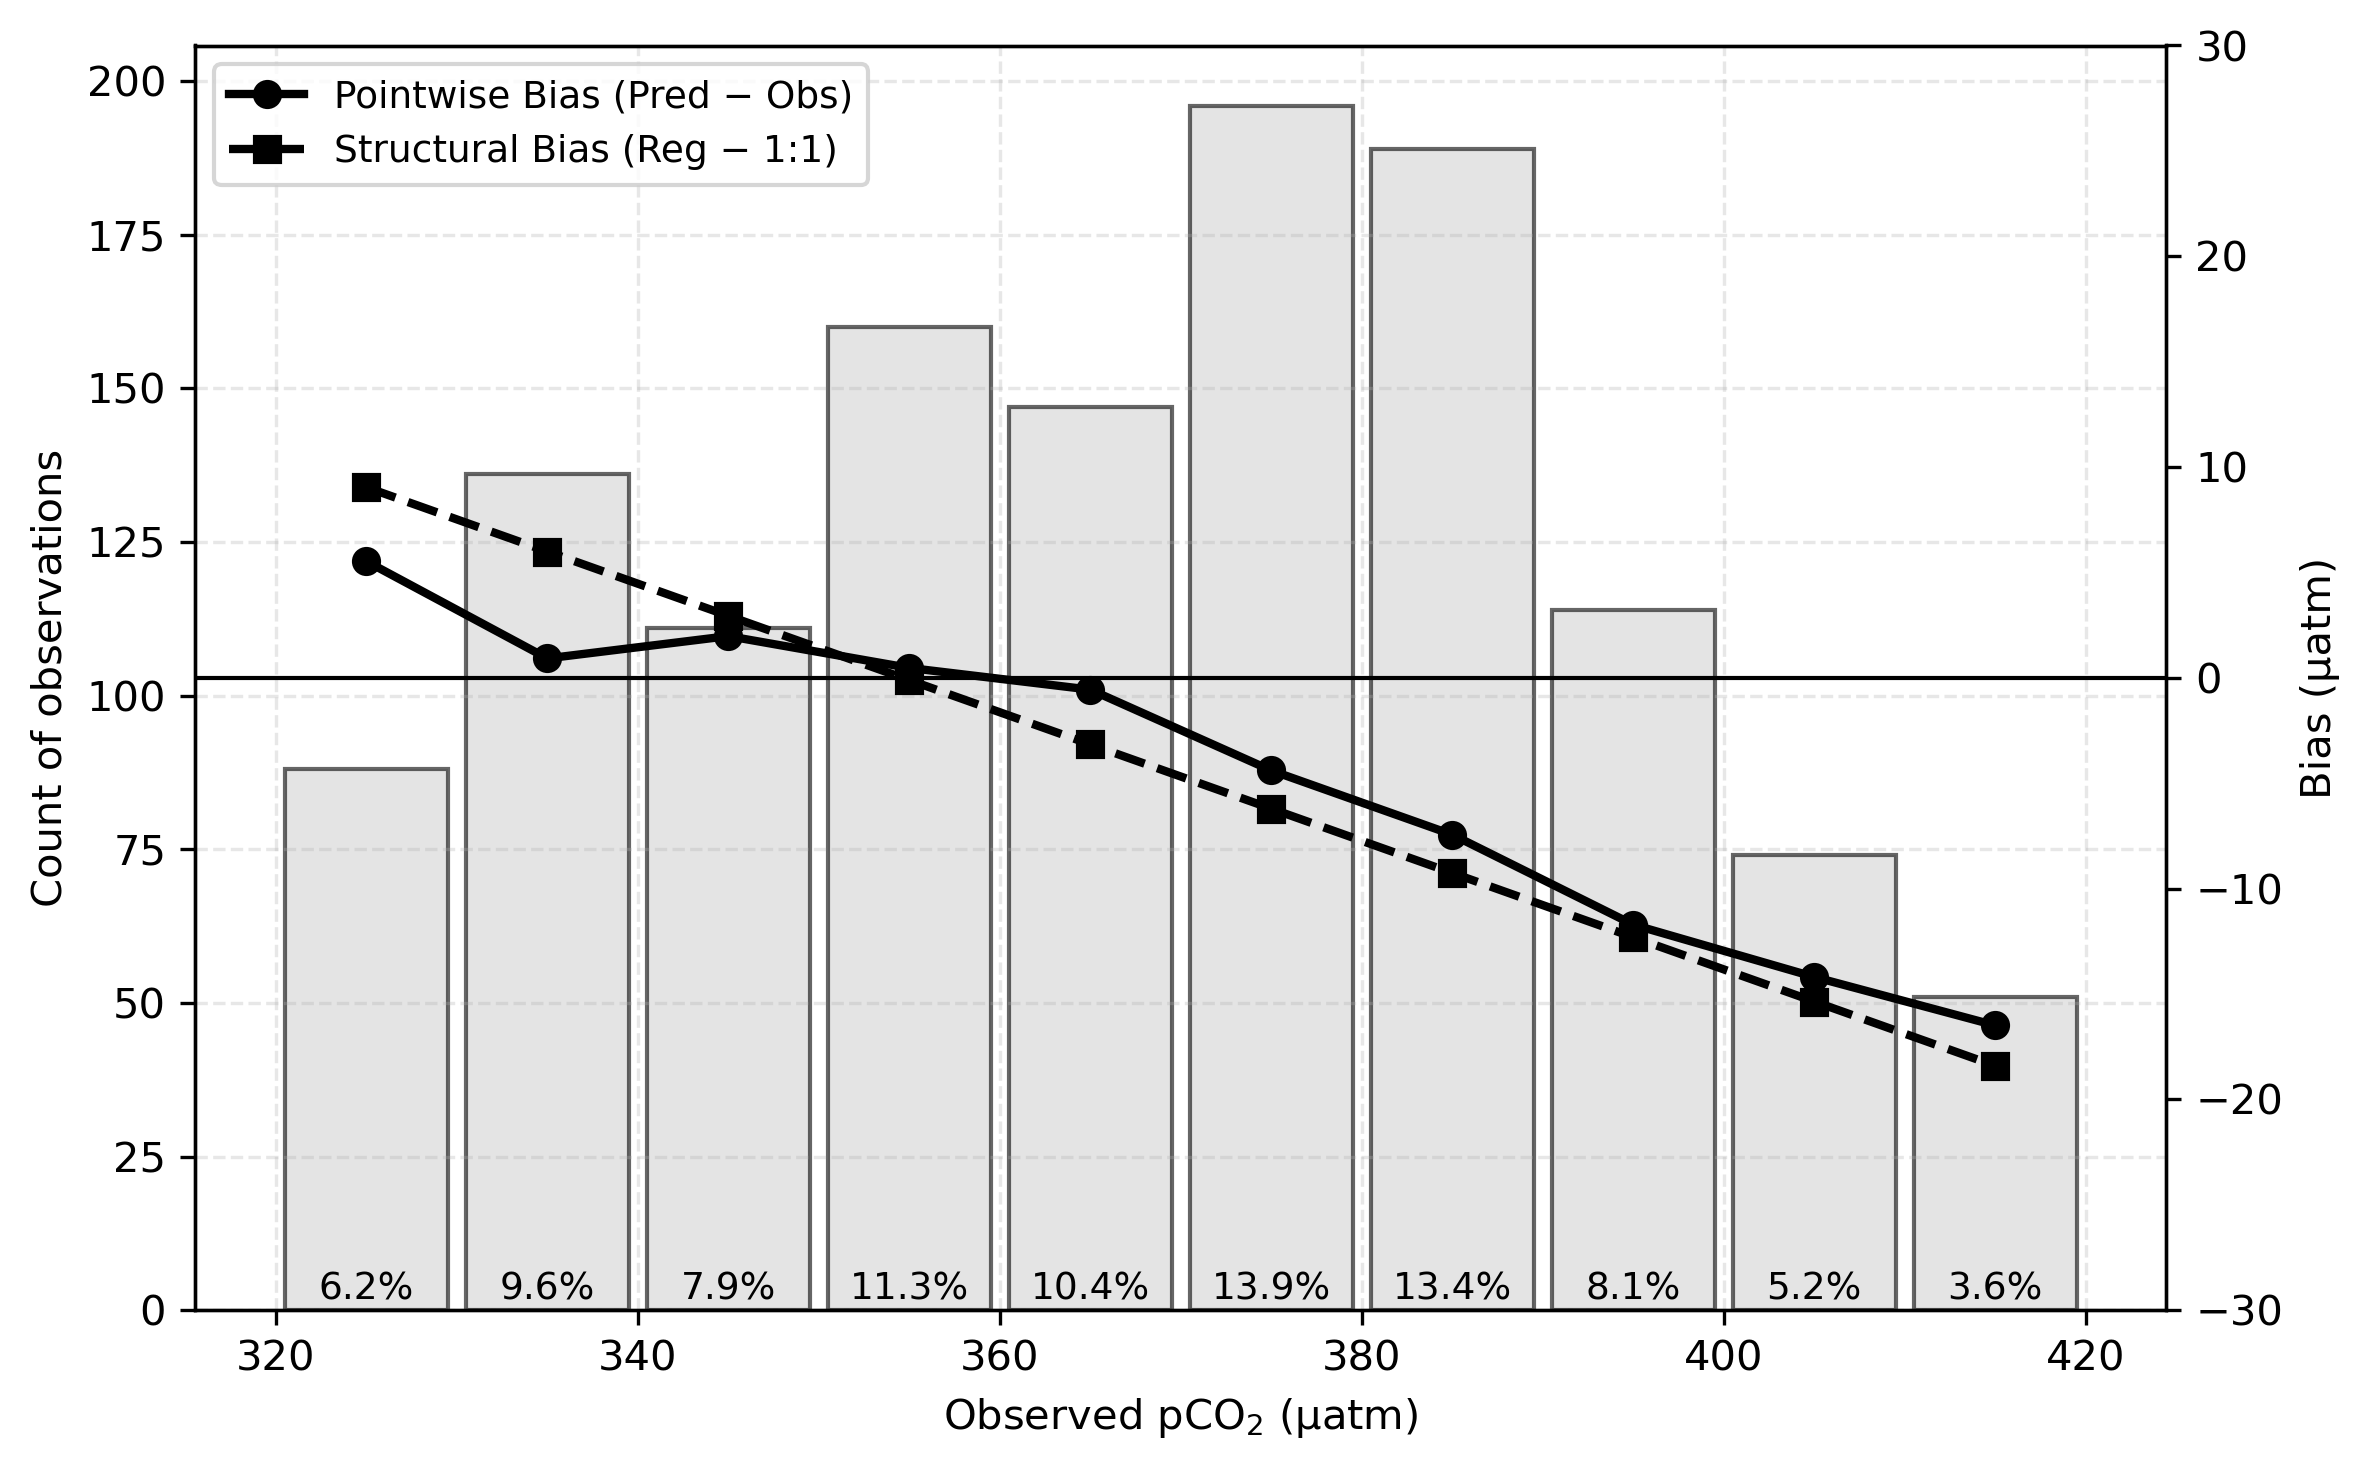

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Fit regression line once
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Define 10-µatm bins from 300 to 400
bins = np.arange(320, 430, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Assign each observed x to a bin
bin_idx = np.digitize(x, bins)
hist_counts = np.array([np.sum(bin_idx == i) for i in range(1, len(bins))])

# Percentages for each bin
N_total = len(x)
hist_pct = (hist_counts / N_total) * 100

# Pointwise bias (actual model error)
point_bias = y - x

# -----------------------------------------------------------
# COMPUTE POINTWISE BIAS PER BIN
# -----------------------------------------------------------
pw_bias = []
for i in range(1, len(bins)):
    mask = (bin_idx == i)
    if np.sum(mask) > 0:
        pw_bias.append(np.mean(point_bias[mask]))
    else:
        pw_bias.append(np.nan)

pw_bias = np.array(pw_bias)

# -----------------------------------------------------------
# COMPUTE STRUCTURAL REGRESSION BIAS PER BIN
# -----------------------------------------------------------
reg_bias = []
for xc in bin_centers:
    y_reg = slope * xc + intercept   # regression prediction at bin center
    diff = y_reg - xc                # difference from 1:1
    reg_bias.append(diff)

reg_bias = np.array(reg_bias)

# -----------------------------------------------------------
# COMBINED HISTOGRAM + BIAS CURVE PLOT
# -----------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(8, 5), dpi=300)

# --- Histogram (primary axis) ---
bar_width = bins[1] - bins[0]
bars = ax1.bar(bin_centers, hist_counts, width=bar_width*0.9,
               color='lightgray', edgecolor='k', alpha=0.6)

#ax1.set_ylim(0, 40)
ax1.set_xlabel('Observed pCO$_2$ (µatm)')
ax1.set_ylabel('Count of observations')
ax1.grid(True, ls='--', alpha=0.3)

# --- Add % labels on top of each histogram bar ---
for xc, height, pct in zip(bin_centers, hist_counts, hist_pct):
    if height > 0:
        ax1.text(xc, 0.5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# --- Bias curves (secondary axis) ---
ax2 = ax1.twinx()
ax2.plot(bin_centers, pw_bias, marker='o', lw=2, color='k',
         label='Pointwise Bias (Pred − Obs)')

ax2.plot(bin_centers, reg_bias, marker='s', ls='--', lw=2, color='k',
         label='Structural Bias (Reg − 1:1)')

# Bias axis range: -30 to +30
ax2.set_ylim(-30, 30)
ax2.set_ylabel('Bias (µatm)')
ax2.axhline(0, color='black', lw=1)

# Legend for the bias curves
ax2.legend(loc='upper left', fontsize=9)

fig.tight_layout()
fig.savefig("figs/bias_analysis.png", dpi=300, bbox_inches='tight')
plt.show()


In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error

# -------------------------------
# Ensure NaN-safe inputs
# -------------------------------
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]

# -------------------------------
# Compute RMSE (sklearn v1.5+ compatible)
# -------------------------------
rmse = np.sqrt(mean_squared_error(x_valid, y_valid))

# -------------------------------
# Absolute prediction error
# -------------------------------
abs_error = np.abs(y_valid - x_valid)

# -------------------------------
# Count how many errors are within ±RMSE
# -------------------------------
within_rmse = np.sum(abs_error <= rmse)

# -------------------------------
# Percentage
# -------------------------------
pct_within_rmse = (within_rmse / len(x_valid)) * 100

# -------------------------------
# Output
# -------------------------------
print(f"RMSE: {rmse:.2f} µatm")
print(f"Percentage of observations within ±RMSE: {pct_within_rmse:.2f}%")
print(f"Count: {within_rmse} out of {len(x_valid)}")


RMSE: 16.04 µatm
Percentage of observations within ±RMSE: 78.12%
Count: 1103 out of 1412


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

# --- Season assignment function ---
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    elif month in [9, 10, 11]:
        return 'Spring'

# --- Convert month_center to datetime ---
df['month_center'] = pd.to_datetime(df['month_center'], errors='coerce')

# --- Extract month ---
df['month'] = df['month_center'].dt.month

# --- Assign season ---
df['season'] = df['month'].apply(get_season)

# -------------------------------
# NaN-safe global KDE scaling
# -------------------------------

# Select only required columns and drop NaNs
df_valid = df[['pco2', 'ensemble_pco2_pred']].dropna()

all_x = df_valid['pco2'].values
all_y = df_valid['ensemble_pco2_pred'].values

# Stack safely
xy = np.vstack([all_x, all_y])

# Compute global density
all_density = gaussian_kde(xy)(xy)

# Global color scale limits
global_vmin = all_density.min()
global_vmax = all_density.max()

print("Done: global density range =", global_vmin, global_vmax)


Done: global density range = 3.353925563074911e-06 0.0006518233422431534


/tmp/ipykernel_1575614/142495832.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


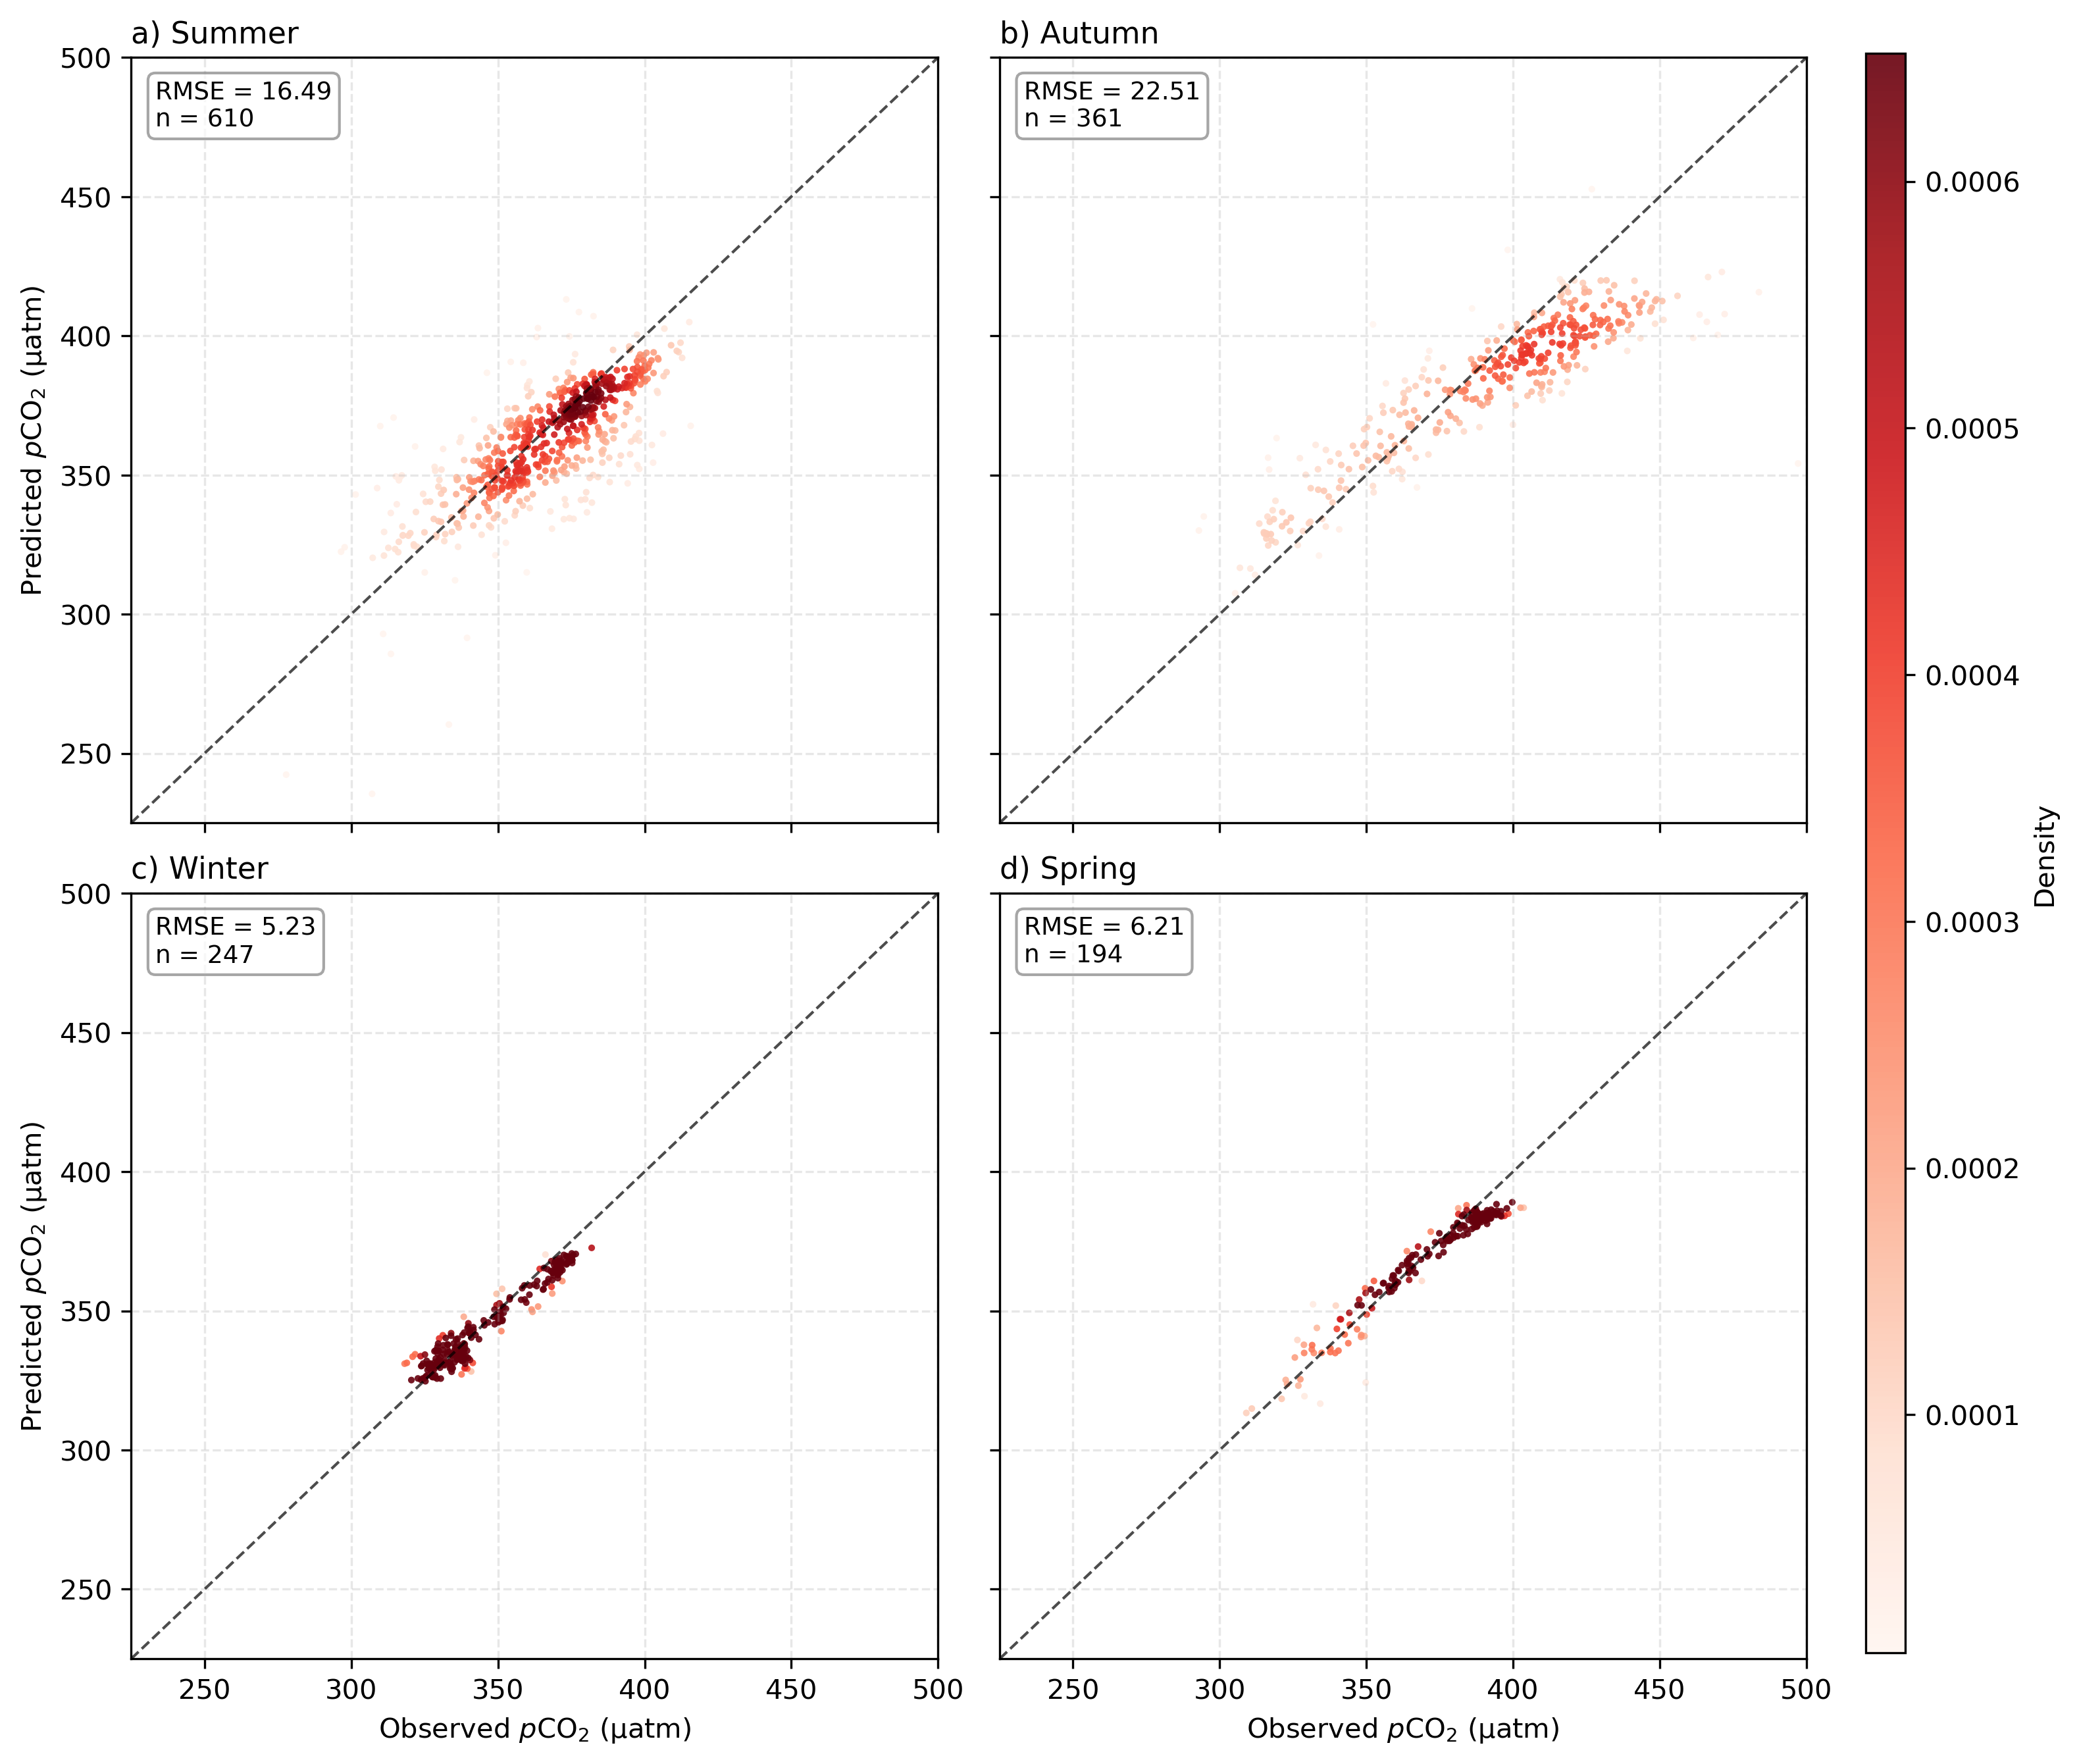

In [12]:
# Prepare subplot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 9), dpi=300, sharex=True, sharey=True)
axs = axs.flatten()

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
letters = ['a) Summer', 'b) Autumn', 'c) Winter', 'd) Spring']
xlim = ylim = (225, 500)

for i, season in enumerate(season_order):
    ax = axs[i]

    # -------------------------------
    # Select season & drop NaNs safely
    # -------------------------------
    data = df.loc[df['season'] == season, ['pco2', 'ensemble_pco2_pred']].dropna()

    # If too few points, skip safely
    if len(data) < 5:
        ax.text(
            0.5, 0.5, f"{season}\nNot enough data",
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=10
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, ls='--', alpha=0.3)
        continue

    x = data['pco2'].values
    y = data['ensemble_pco2_pred'].values

    # -------------------------------
    # KDE density (NaN-safe)
    # -------------------------------
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    idx = density.argsort()
    x, y, density = x[idx], y[idx], density[idx]

    # -------------------------------
    # Scatter plot
    # -------------------------------
    sc = ax.scatter(
        x, y,
        c=density,
        s=6,
        alpha=0.9,
        edgecolor='none',
        cmap='Reds',
        vmin=global_vmin,
        vmax=global_vmax
    )

    # -------------------------------
    # Axes setup
    # -------------------------------
    if i % 2 == 0:
        ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
    if i >= 2:
        ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, ls='--', alpha=0.3)

    # -------------------------------
    # 1:1 line
    # -------------------------------
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], 'k--', lw=1, alpha=0.7)

    # -------------------------------
    # Metrics (sklearn v1.5+ compatible)
    # -------------------------------
    rmse = np.sqrt(mean_squared_error(x, y))
    n = len(x)

    # -------------------------------
    # Stats box
    # -------------------------------
    stats_text = f"RMSE = {rmse:.2f}\nn = {n}"

    ax.text(
        0.03, 0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
    )

    # -------------------------------
    # Panel label
    # -------------------------------
    ax.text(
        0, 1.05,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        va='top',
        ha='left'
    )

# -------------------------------
# Shared colorbar
# -------------------------------
cbar_ax = fig.add_axes([0.95, 0.068, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Density')

# -------------------------------
# Final layout and save
# -------------------------------
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.savefig("figs/pco2_density_by_season.png", dpi=300, bbox_inches='tight')
plt.show()
